<a href="https://colab.research.google.com/github/nathanfalima189/tennis-atp-2024-analysis/blob/main/notebooks/tennis_atp_2024_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
from google.colab import files
uploaded = files.upload()

Saving atp_matches_2024.csv to atp_matches_2024.csv


In [7]:
df_atp = pd.read_csv("atp_matches_2024.csv")

df_atp.head()

,tourney_id,tourney_name,surface,draw_size,tourney_level,tourney_date,match_num,winner_id,winner_seed,winner_entry,...,l_1stIn,l_1stWon,l_2ndWon,l_SvGms,l_bpSaved,l_bpFaced,winner_rank,winner_rank_points,loser_rank,loser_rank_points
0,2024-0339,Brisbane,Hard,32,A,20240101,300,105777,2.0,NaN,...,58.0,44.0,16.0,11.0,8.0,9.0,14.0,2570.0,8.0,3660.0
1,2024-0339,Brisbane,Hard,32,A,20240101,299,208029,1.0,NaN,...,35.0,31.0,10.0,11.0,5.0,7.0,8.0,3660.0,39.0,1122.0
2,2024-0339,Brisbane,Hard,32,A,20240101,298,105777,2.0,NaN,...,39.0,24.0,14.0,10.0,5.0,7.0,14.0,2570.0,55.0,902.0
3,2024-0339,Brisbane,Hard,32,A,20240101,297,208029,1.0,NaN,...,51.0,31.0,16.0,10.0,3.0,5.0,8.0,3660.0,116.0,573.0
4,2024-0339,Brisbane,Hard,32,A,20240101,296,126128,NaN,NaN,...,37.0,27.0,16.0,10.0,5.0,8.0,39.0,1122.0,44.0,1021.0


In [8]:
#Exemplo para verificar as colunas

df_atp.columns

Index(['tourney_id', 'tourney_name', 'surface', 'draw_size', 'tourney_level',
       'tourney_date', 'match_num', 'winner_id', 'winner_seed', 'winner_entry',
       'winner_name', 'winner_hand', 'winner_ht', 'winner_ioc', 'winner_age',
       'loser_id', 'loser_seed', 'loser_entry', 'loser_name', 'loser_hand',
       'loser_ht', 'loser_ioc', 'loser_age', 'score', 'best_of', 'round',
       'minutes', 'w_ace', 'w_df', 'w_svpt', 'w_1stIn', 'w_1stWon', 'w_2ndWon',
       'w_SvGms', 'w_bpSaved', 'w_bpFaced', 'l_ace', 'l_df', 'l_svpt',
       'l_1stIn', 'l_1stWon', 'l_2ndWon', 'l_SvGms', 'l_bpSaved', 'l_bpFaced',
       'winner_rank', 'winner_rank_points', 'loser_rank', 'loser_rank_points'],
      dtype='object')

In [9]:
#Jogador com mais vitórias em 2024
df_atp["winner_name"].value_counts().head(20)

,count
winner_name,
Jannik Sinner,74
Alexander Zverev,69
Carlos Alcaraz,54
Taylor Fritz,53
Casper Ruud,52
Alex De Minaur,48
Grigor Dimitrov,46
Holger Rune,46
Daniil Medvedev,46


In [10]:
#Jogadores com mais aces no ano

df_atp.groupby("winner_name")["w_ace"].sum().sort_values(ascending=False).head(5)

,w_ace
winner_name,
Alexander Zverev,647.0
Taylor Fritz,605.0
Hubert Hurkacz,570.0
Jannik Sinner,552.0
Grigor Dimitrov,434.0


In [11]:
#Jogos mais longos de 2024
df_atp.sort_values("minutes", ascending=False)[["winner_name","loser_name","minutes"]].head(5)

,winner_name,loser_name,minutes
2214,Daniel Evans,Karen Khachanov,335.0
181,Felix Auger Aliassime,Dominic Thiem,299.0
155,Daniel Elahi Galan,Jason Kubler,299.0
234,Adrian Mannarino,Ben Shelton,286.0
163,Pavel Kotov,Arthur Rinderknech,282.0


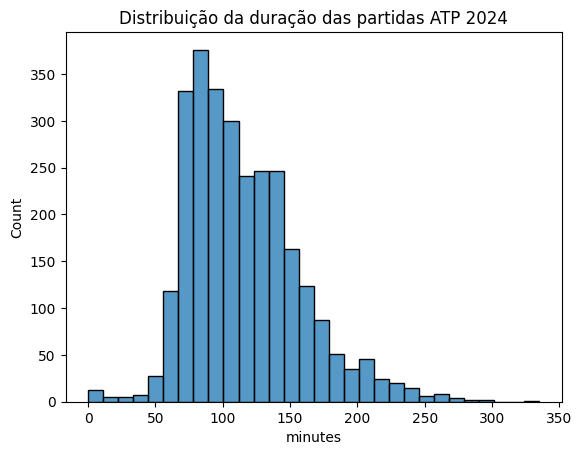

In [12]:
#distruibuição das partidas
import seaborn as sns

sns.histplot(df_atp["minutes"], bins=30)
plt.title("Distribuição da duração das partidas ATP 2024")
plt.show()

In [13]:
#países com mais vitórias

df_atp["winner_ioc"].value_counts().head(10)

,count
winner_ioc,
USA,363
ITA,289
FRA,263
AUS,212
ESP,184
RUS,168
ARG,165
GER,158
SRB,99


In [15]:
#quantidade de torneios por Tipo

df_tournaments = df_atp[["tourney_name", "tourney_level"]].drop_duplicates() #tirar os que aparecem duplicados

df_tournaments["tourney_level"].value_counts()

,count
tourney_level,
D,91
A,53
M,9
G,4
F,2
O,1


In [17]:
#Países que dominam a supericie do Saibro
df_clay = df_atp[df_atp["surface"] == "Clay"]
df_clay["winner_ioc"].value_counts().head(10)

,count
winner_ioc,
ARG,124
ITA,101
ESP,81
FRA,66
GER,64
USA,63
RUS,45
SRB,43
CHI,29


In [18]:
#Países que dominam a supericie rápida
df_hard = df_atp[df_atp["surface"] == "Hard"]
df_hard["winner_ioc"].value_counts().head(10)

,count
winner_ioc,
USA,230
FRA,166
ITA,148
AUS,147
RUS,114
ESP,87
GER,78
CZE,67
GBR,52


In [19]:
#Países que mais venceram na grama
df_hard = df_atp[df_atp["surface"] == "Grass"]
df_hard["winner_ioc"].value_counts().head(10)

,count
winner_ioc,
USA,70
ITA,40
AUS,38
FRA,31
GBR,22
ESP,16
GER,16
SRB,11
RUS,9
